# 1. Initial check
## GPU Check

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())
else:
    print("Using CPU")

CUDA available: True
GPU name: NVIDIA H100 80GB HBM3
GPU count: 1


# 2. Dataset

In [2]:
# Check if the dataset path exists and list files
# import os

# # Check if the path exists and list files
# root = "/storage/ice1/shared/d-pace_community/makerspace-datasets/AVs/CURE-TSR/"
# print("Exists:", os.path.exists(root))
# print("Files:", os.listdir(root))

# # Check the contents of the base directory
# base = "/storage/ice1/shared/d-pace_community/makerspace-datasets/AVs/CURE-TSR/Real_Test"
# print(os.listdir(base)[:10])

# # Check the contents of one class directory
# sample_class = os.listdir(base)[0]
# sample_path = os.path.join(base, sample_class)
# print("Class:", sample_class)
# print("Files:", os.listdir(sample_path)[:5])

### 2.1 Dataset interpretation
- Real_Train
    - Darkening-1
        - '01_14_04_01_0033.bmp'
        - '01_01_04_01_0276.bmp'
        - ...
    - Rain-3
    - Haze-5 （challenge type + level）
    - ...
- Real_Test
- Unreal_Train
- Unreal_Test

Explaination:
- The name format of the provided images are as follows: "sequenceType_signType_challengeType_challengeLevel_Index.bmp"
    - sequenceType: 
        - 01 - Real data 
        - 02 - Unreal data
    - signType: 
        - 01 - speed_limit 
        - 02 - goods_vehicles 
        - 03 - no_overtaking 
        - 04 - no_stopping 
        - 05 - no_parking 
        - 06 - stop 
        - 07 - bicycle 
        - 08 - hump 
        - 09 - no_left 
        - 10 - no_right 
        - 11 - priority_to 
        - 12 - no_entry 
        - 13 - yield 
        - 14 - parking
    - challengeType: 
        - 00 - No challenge 
        - 01 - Decolorization 
        - 02 - Lens blur 
        - 03 - Codec error 
        - 04 - Darkening 
        - 05 - Dirty lens 
        - 06 - Exposure 
        - 07 - Gaussian blur 
        - 08 - Noise 
        - 09 - Rain 
        - 10 - Shadow 
        - 11 - Snow 
        - 12 - Haze
    - challengeLevel: A number in between [01-05] where 01 is the least severe and 05 is the most severe challenge.

In [3]:
import os
from PIL import Image
from torch.utils.data import Dataset

class TrafficSignDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self._load_data()

        if len(self.samples) == 0:
            raise ValueError(f"No .bmp files found in {self.root_dir}")

    def _parse_filename(self, filename):
        """
        filename format:
        sequenceType_signType_challengeType_challengeLevel_Index.bmp
        """
        name = filename.replace(".bmp", "")
        parts = name.split("_")

        sequenceType = int(parts[0])   # 01 real / 02 unreal
        signType = int(parts[1])       # signType label
        challengeType = int(parts[2])  # corruption type
        challengeLevel = int(parts[3]) # severity

        return sequenceType, signType, challengeType, challengeLevel

    def _load_data(self):
        for root, _, files in os.walk(self.root_dir):
            for f in files:
                if f.lower().endswith(".bmp"):
                    full_path = os.path.join(root, f)
                    sequenceType, signType, challengeType, challengeLevel = self._parse_filename(f)

                    self.samples.append({
                        "path": full_path,
                        "sequenceType": sequenceType,         # 1 = real, 2 = unreal
                        "signType": signType - 1,          # make signType label 0-based
                        "challengeType": challengeType,
                        "challengeLevel": challengeLevel,
                        "filename": f
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(sample["path"]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return {
            "image": img,
            "sequenceType": sample["sequenceType"],
            "signType": sample["signType"],
            "challengeType": sample["challengeType"],
            "challengeLevel": sample["challengeLevel"],
            "filename": sample["filename"],
            "path": sample["path"]
        }

In [4]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

root = "/storage/ice1/shared/d-pace_community/makerspace-datasets/AVs/CURE-TSR/"

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

real_train_dataset      = TrafficSignDataset(os.path.join(root, "Real_Train"), transform=transform)
real_test_dataset       = TrafficSignDataset(os.path.join(root, "Real_Test"), transform=transform)
unreal_train_dataset    = TrafficSignDataset(os.path.join(root, "Unreal_Train"), transform=transform)
unreal_test_dataset     = TrafficSignDataset(os.path.join(root, "Unreal_Test"), transform=transform)

print("real_train_dataset:", len(real_train_dataset))
print("real_test_dataset:", len(real_test_dataset))
print("unreal_train_dataset:", len(unreal_train_dataset))
print("unreal_test_dataset:", len(unreal_test_dataset))

real_train_dataset: 444806
real_test_dataset: 203374
unreal_train_dataset: 1098160
unreal_test_dataset: 459760


In [5]:
Real_Train = DataLoader(real_train_dataset, batch_size=64, shuffle=True)
Real_Test = DataLoader(real_test_dataset, batch_size=64, shuffle=False)
Unreal_Train = DataLoader(unreal_train_dataset, batch_size=64, shuffle=True)
Unreal_Test = DataLoader(unreal_test_dataset, batch_size=64, shuffle=False)

In [6]:
# test dataset loading
print("First 2 samples from each dataset:")

for i in range(2):
    print("\n[Real_Train]", real_train_dataset.samples[i])
    print("[Real_Test]", real_test_dataset.samples[i])
    print("[Unreal_Train]", unreal_train_dataset.samples[i])
    print("[Unreal_Test]", unreal_test_dataset.samples[i])

First 2 samples from each dataset:

[Real_Train] {'path': '/storage/ice1/shared/d-pace_community/makerspace-datasets/AVs/CURE-TSR/Real_Train/Darkening-1/01_14_04_01_0033.bmp', 'sequenceType': 1, 'signType': 13, 'challengeType': 4, 'challengeLevel': 1, 'filename': '01_14_04_01_0033.bmp'}
[Real_Test] {'path': '/storage/ice1/shared/d-pace_community/makerspace-datasets/AVs/CURE-TSR/Real_Test/Darkening-1/01_14_04_01_0033.bmp', 'sequenceType': 1, 'signType': 13, 'challengeType': 4, 'challengeLevel': 1, 'filename': '01_14_04_01_0033.bmp'}
[Unreal_Train] {'path': '/storage/ice1/shared/d-pace_community/makerspace-datasets/AVs/CURE-TSR/Unreal_Train/Darkening-1/02_01_04_01_0926.bmp', 'sequenceType': 2, 'signType': 0, 'challengeType': 4, 'challengeLevel': 1, 'filename': '02_01_04_01_0926.bmp'}
[Unreal_Test] {'path': '/storage/ice1/shared/d-pace_community/makerspace-datasets/AVs/CURE-TSR/Unreal_Test/Darkening-1/02_14_04_01_0572.bmp', 'sequenceType': 2, 'signType': 13, 'challengeType': 4, 'challenge

### 2.2 Data split

In [7]:
import torch
from torch.utils.data import Subset, DataLoader
import numpy as np

def make_small_loader(loader, fraction=0.1, batch_size=None, shuffle=True, seed=42):
    """
    从现有 DataLoader 对应的 dataset 中随机抽取一部分样本，重新构建小 DataLoader
    fraction=0.1 表示只取 10% 数据
    """
    dataset = loader.dataset
    n = len(dataset)
    small_n = max(1, int(n * fraction))

    rng = np.random.default_rng(seed)
    indices = rng.choice(n, size=small_n, replace=False)

    small_dataset = Subset(dataset, indices)

    new_loader = DataLoader(
        small_dataset,
        batch_size=batch_size if batch_size is not None else loader.batch_size,
        shuffle=shuffle,
        num_workers=loader.num_workers,
        pin_memory=getattr(loader, "pin_memory", False)
    )
    return new_loader

In [8]:
small_Real_Train   = make_small_loader(Real_Train,   fraction=0.5, shuffle=False)
small_Real_Test    = make_small_loader(Real_Test,    fraction=0.5, shuffle=False)
small_Unreal_Train = make_small_loader(Unreal_Train, fraction=0.5, shuffle=False)
small_Unreal_Test  = make_small_loader(Unreal_Test,  fraction=0.5, shuffle=False)

# 3. Metrics

metrics needed:

- logits: [N, K]
- probs: [N, K]
- labels: [N]
- accept_mask: [N]，布尔值，表示是否接受预测
- ood_scores: [N]，越大越像 OOD 或越不确定
- id_scores: [N]，ID 数据上的对应分数

In [9]:
import math
import numpy as np
import torch
import torch.nn.functional as F


# =========================================================
# Basic helpers
# =========================================================
def to_probs(logits: torch.Tensor) -> torch.Tensor:
    """
    Convert logits [N, K] to probabilities [N, K].
    """
    return torch.softmax(logits, dim=1)


def safe_log(x: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    return torch.log(torch.clamp(x, min=eps))

In [10]:
# =========================================================
# 1. Clean Accuracy
# =========================================================
def clean_accuracy_from_probs(probs: torch.Tensor, labels: torch.Tensor) -> float:
    """
    probs: [N, K]
    labels: [N]
    """
    preds = probs.argmax(dim=1)
    acc = (preds == labels).float().mean().item()
    return float(acc)


def clean_accuracy_from_logits(logits: torch.Tensor, labels: torch.Tensor) -> float:
    return clean_accuracy_from_probs(to_probs(logits), labels)


## 3.1 Uncertainty / Calibration
### 3.1.1 NLL

In [11]:
# =========================================================
# 2. NLL (Negative Log Likelihood)
# =========================================================
def negative_log_likelihood(probs: torch.Tensor, labels: torch.Tensor) -> float:
    """
    Multi-class NLL.
    Lower is better.
    """
    true_class_probs = probs[torch.arange(len(labels)), labels]
    nll = -safe_log(true_class_probs).mean().item()
    return float(nll)

### 3.1.2 Brier

In [12]:
# =========================================================
# 3. Brier Score
# =========================================================
def brier_score(probs: torch.Tensor, labels: torch.Tensor, num_classes: int = None) -> float:
    """
    Multi-class Brier score.
    Lower is better.
    """
    if num_classes is None:
        num_classes = probs.shape[1]

    one_hot = F.one_hot(labels, num_classes=num_classes).float()
    bs = ((probs - one_hot) ** 2).sum(dim=1).mean().item()
    return float(bs)

### 3.1.3 Calibration

In [13]:
# =========================================================
# 4. Calibration
# =========================================================
def expected_calibration_error(
    probs: torch.Tensor,
    labels: torch.Tensor,
    n_bins: int = 15
) -> float:
    """
    Standard ECE.
    Lower is better.
    """
    confidences, predictions = probs.max(dim=1)
    accuracies = predictions.eq(labels).float()

    bin_boundaries = torch.linspace(0, 1, n_bins + 1, device=probs.device)
    ece = torch.zeros(1, device=probs.device)

    for i in range(n_bins):
        lower = bin_boundaries[i]
        upper = bin_boundaries[i + 1]

        if i == 0:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences > lower) & (confidences <= upper)

        prop_in_bin = in_bin.float().mean()
        if prop_in_bin.item() > 0:
            acc_in_bin = accuracies[in_bin].mean()
            conf_in_bin = confidences[in_bin].mean()
            ece += torch.abs(conf_in_bin - acc_in_bin) * prop_in_bin

    return float(ece.item())


def calibration_table(
    probs: torch.Tensor,
    labels: torch.Tensor,
    n_bins: int = 15
):
    """
    Returns a list of per-bin stats for reliability diagrams.
    """
    confidences, predictions = probs.max(dim=1)
    accuracies = predictions.eq(labels).float()

    bin_boundaries = torch.linspace(0, 1, n_bins + 1, device=probs.device)
    rows = []

    for i in range(n_bins):
        lower = bin_boundaries[i]
        upper = bin_boundaries[i + 1]

        if i == 0:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences > lower) & (confidences <= upper)

        count = int(in_bin.sum().item())
        if count > 0:
            rows.append({
                "bin_lower": float(lower.item()),
                "bin_upper": float(upper.item()),
                "count": count,
                "avg_confidence": float(confidences[in_bin].mean().item()),
                "avg_accuracy": float(accuracies[in_bin].mean().item()),
            })
        else:
            rows.append({
                "bin_lower": float(lower.item()),
                "bin_upper": float(upper.item()),
                "count": 0,
                "avg_confidence": float("nan"),
                "avg_accuracy": float("nan"),
            })

    return rows

### 3.1.4 OOD entropy/confidence

In [14]:
# =========================================================
# 5. OOD Detection
# =========================================================
def max_softmax_probability(probs: torch.Tensor) -> torch.Tensor:
    """
    Higher MSP => more likely ID
    """
    return probs.max(dim=1).values


def predictive_entropy(probs: torch.Tensor) -> torch.Tensor:
    """
    Higher entropy => more uncertain / more likely OOD
    """
    return -(probs * safe_log(probs)).sum(dim=1)


def _binary_roc_auc_from_scores(id_scores: np.ndarray, ood_scores: np.ndarray, higher_means_ood: bool = True) -> float:
    """
    Simple AUROC implementation without sklearn.

    id_scores: scores on ID samples
    ood_scores: scores on OOD samples
    higher_means_ood:
        True  -> larger score = more OOD
        False -> larger score = more ID
    """
    y_true = np.concatenate([np.zeros(len(id_scores)), np.ones(len(ood_scores))])  # 0=ID, 1=OOD
    scores = np.concatenate([id_scores, ood_scores])

    if not higher_means_ood:
        scores = -scores

    order = np.argsort(scores)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(scores)) + 1

    n_ood = len(ood_scores)
    n_id = len(id_scores)

    sum_ranks_ood = ranks[y_true == 1].sum()
    auc = (sum_ranks_ood - n_ood * (n_ood + 1) / 2) / (n_ood * n_id)
    return float(auc)


def ood_auroc_from_entropy(id_probs: torch.Tensor, ood_probs: torch.Tensor) -> float:
    """
    Higher entropy => more OOD
    """
    id_scores = predictive_entropy(id_probs).detach().cpu().numpy()
    ood_scores = predictive_entropy(ood_probs).detach().cpu().numpy()
    return _binary_roc_auc_from_scores(id_scores, ood_scores, higher_means_ood=True)


def ood_auroc_from_msp(id_probs: torch.Tensor, ood_probs: torch.Tensor) -> float:
    """
    Lower MSP => more OOD
    """
    id_scores = max_softmax_probability(id_probs).detach().cpu().numpy()
    ood_scores = max_softmax_probability(ood_probs).detach().cpu().numpy()
    return _binary_roc_auc_from_scores(id_scores, ood_scores, higher_means_ood=False)


def ood_detection_summary(id_probs: torch.Tensor, ood_probs: torch.Tensor):
    return {
        "OOD_AUROC_entropy": ood_auroc_from_entropy(id_probs, ood_probs),
        "OOD_AUROC_MSP": ood_auroc_from_msp(id_probs, ood_probs),
        "ID_mean_entropy": float(predictive_entropy(id_probs).mean().item()),
        "OOD_mean_entropy": float(predictive_entropy(ood_probs).mean().item()),
        "ID_mean_MSP": float(max_softmax_probability(id_probs).mean().item()),
        "OOD_mean_MSP": float(max_softmax_probability(ood_probs).mean().item()),
    }

## 3.2 Selective Classification
### 3.2.1 Risk and Coverage

In [15]:
# =========================================================
# 6. Risk and Coverage
# =========================================================
def coverage(accept_mask: torch.Tensor) -> float:
    """
    Coverage = fraction of accepted samples
    """
    return float(accept_mask.float().mean().item())


def selective_risk(probs: torch.Tensor, labels: torch.Tensor, accept_mask: torch.Tensor) -> float:
    """
    Risk over accepted samples only.
    Lower is better.
    """
    accept_mask = accept_mask.bool()
    if accept_mask.sum().item() == 0:
        return float("nan")

    preds = probs.argmax(dim=1)
    errors = (preds != labels).float()
    risk = errors[accept_mask].mean().item()
    return float(risk)


def risk_coverage_summary(probs: torch.Tensor, labels: torch.Tensor, accept_mask: torch.Tensor):
    return {
        "coverage": coverage(accept_mask),
        "risk": selective_risk(probs, labels, accept_mask),
    }

## 3.3 Corruption Robustness
### 3.3.1 Mean Corruption Error and Relative mCE

In [16]:
# =========================================================
# 7. Corruption Robustness: mCE and Relative mCE
# =========================================================
def corruption_error(error_rates_across_severities, alexnet_error_across_severities):
    """
    CE for one corruption type.

    error_rates_across_severities: list of model error rates at severity 1..5
    alexnet_error_across_severities: list of AlexNet error rates at severity 1..5
    """
    num = np.sum(error_rates_across_severities)
    den = np.sum(alexnet_error_across_severities)
    return float(num / den)


def relative_corruption_error(
    error_rates_across_severities,
    clean_error,
    alexnet_error_across_severities,
    alexnet_clean_error
):
    """
    Relative CE for one corruption type.
    """
    num = np.sum(error_rates_across_severities) - clean_error
    den = np.sum(alexnet_error_across_severities) - alexnet_clean_error
    return float(num / den)


def mean_corruption_error(
    corruption_dict,
    alexnet_corruption_dict
):
    """
    corruption_dict:
        {
            'gaussian_noise': [e1, e2, e3, e4, e5],
            'blur': [...],
            ...
        }

    alexnet_corruption_dict:
        same structure with AlexNet errors
    """
    ces = []
    for corruption_name in corruption_dict:
        ce = corruption_error(
            corruption_dict[corruption_name],
            alexnet_corruption_dict[corruption_name]
        )
        ces.append(ce)
    return float(np.mean(ces))


def relative_mce(
    corruption_dict,
    clean_error,
    alexnet_corruption_dict,
    alexnet_clean_error
):
    rces = []
    for corruption_name in corruption_dict:
        rce = relative_corruption_error(
            corruption_dict[corruption_name],
            clean_error,
            alexnet_corruption_dict[corruption_name],
            alexnet_clean_error
        )
        rces.append(rce)
    return float(np.mean(rces))

## 3.4 Metrics summrization

In [17]:
# =========================================================
# 8. Unified metrics summary
# =========================================================
def evaluate_id_metrics(
    probs: torch.Tensor,
    labels: torch.Tensor,
    accept_mask: torch.Tensor = None,
    n_bins: int = 15
):
    results = {
        "clean_accuracy": clean_accuracy_from_probs(probs, labels),
        "NLL": negative_log_likelihood(probs, labels),
        "Brier": brier_score(probs, labels),
        "ECE": expected_calibration_error(probs, labels, n_bins=n_bins),
    }

    if accept_mask is not None:
        results["coverage"] = coverage(accept_mask)
        results["risk"] = selective_risk(probs, labels, accept_mask)

    return results


def evaluate_ood_metrics(
    id_probs: torch.Tensor,
    ood_probs: torch.Tensor
):
    return ood_detection_summary(id_probs, ood_probs)


def evaluate_corruption_metrics(
    corruption_dict,
    clean_error,
    alexnet_corruption_dict,
    alexnet_clean_error
):
    return {
        "mCE": mean_corruption_error(corruption_dict, alexnet_corruption_dict),
        "Relative_mCE": relative_mce(
            corruption_dict,
            clean_error,
            alexnet_corruption_dict,
            alexnet_clean_error
        )
    }


def evaluate_all_metrics(
    id_probs: torch.Tensor,
    id_labels: torch.Tensor,
    ood_probs: torch.Tensor = None,
    accept_mask: torch.Tensor = None,
    corruption_dict = None,
    clean_error: float = None,
    alexnet_corruption_dict = None,
    alexnet_clean_error: float = None,
    n_bins: int = 15
):
    results = {}
    results.update(
        evaluate_id_metrics(
            probs=id_probs,
            labels=id_labels,
            accept_mask=accept_mask,
            n_bins=n_bins
        )
    )

    if ood_probs is not None:
        results.update(
            evaluate_ood_metrics(
                id_probs=id_probs,
                ood_probs=ood_probs
            )
        )

    if (
        corruption_dict is not None
        and clean_error is not None
        and alexnet_corruption_dict is not None
        and alexnet_clean_error is not None
    ):
        results.update(
            evaluate_corruption_metrics(
                corruption_dict=corruption_dict,
                clean_error=clean_error,
                alexnet_corruption_dict=alexnet_corruption_dict,
                alexnet_clean_error=alexnet_clean_error
            )
        )

    return results

## 3.5 Reusable evaluation helpers

In [18]:
# =========================================================
# 9. Collect model outputs from a dataloader
# =========================================================
@torch.no_grad()
def collect_probs_and_labels(model, loader, device="cuda"):
    model.eval()
    all_probs = []
    all_labels = []

    for batch in loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        logits = model(images)
        probs = to_probs(logits)

        all_probs.append(probs.cpu())
        all_labels.append(labels.cpu())

    return torch.cat(all_probs, dim=0), torch.cat(all_labels, dim=0)


@torch.no_grad()
def collect_logits_probs_labels(model, loader, device="cuda"):
    model.eval()
    all_logits = []
    all_probs = []
    all_labels = []

    for batch in loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        logits = model(images)
        probs = to_probs(logits)

        all_logits.append(logits.cpu())
        all_probs.append(probs.cpu())
        all_labels.append(labels.cpu())

    return (
        torch.cat(all_logits, dim=0),
        torch.cat(all_probs, dim=0),
        torch.cat(all_labels, dim=0),
    )

In [19]:
# =========================================================
# 10. Acceptance masks for operating envelope / uncertainty gating
# =========================================================
def accept_by_msp(probs: torch.Tensor, threshold: float) -> torch.Tensor:
    return max_softmax_probability(probs) >= threshold


def accept_by_entropy(probs: torch.Tensor, threshold: float) -> torch.Tensor:
    return predictive_entropy(probs) <= threshold


def combined_accept_mask(
    probs: torch.Tensor,
    msp_threshold: float = None,
    entropy_threshold: float = None
) -> torch.Tensor:
    mask = torch.ones(len(probs), dtype=torch.bool)

    if msp_threshold is not None:
        mask = mask & accept_by_msp(probs, msp_threshold)

    if entropy_threshold is not None:
        mask = mask & accept_by_entropy(probs, entropy_threshold)

    return mask

In [20]:
# =========================================================
# 11. Risk-coverage curve helper
# =========================================================
def risk_coverage_curve_from_msp(
    probs: torch.Tensor,
    labels: torch.Tensor,
    num_thresholds: int = 50
):
    scores = max_softmax_probability(probs)
    thresholds = torch.linspace(float(scores.min()), float(scores.max()), num_thresholds)

    curve = []
    for t in thresholds:
        mask = scores >= t
        curve.append({
            "threshold": float(t.item()),
            "coverage": coverage(mask),
            "risk": selective_risk(probs, labels, mask),
        })
    return curve


def risk_coverage_curve_from_entropy(
    probs: torch.Tensor,
    labels: torch.Tensor,
    num_thresholds: int = 50
):
    scores = predictive_entropy(probs)
    thresholds = torch.linspace(float(scores.min()), float(scores.max()), num_thresholds)

    curve = []
    for t in thresholds:
        mask = scores <= t
        curve.append({
            "threshold": float(t.item()),
            "coverage": coverage(mask),
            "risk": selective_risk(probs, labels, mask),
        })
    return curve

In [21]:
# =========================================================
# 12. Corruption evaluation template
# =========================================================
def build_corruption_error_dict(results_by_corruption_and_severity):
    """
    Input:
        {
            "gaussian_noise": {1: err1, 2: err2, 3: err3, 4: err4, 5: err5},
            "blur": {1: err1, 2: err2, 3: err3, 4: err4, 5: err5},
        }

    Output:
        {
            "gaussian_noise": [err1, err2, err3, err4, err5],
            "blur": [err1, err2, err3, err4, err5],
        }
    """
    corruption_dict = {}
    for corruption_name, sev_dict in results_by_corruption_and_severity.items():
        corruption_dict[corruption_name] = [sev_dict[s] for s in sorted(sev_dict.keys())]
    return corruption_dict

# 4. Baseline

In [22]:
# =========================================================
# Section 5 helpers
# =========================================================
from torch.utils.data import Subset, DataLoader
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

def unwrap_dataset(dataset):
    """
    If dataset is a Subset, return (base_dataset, indices_in_base_dataset).
    Otherwise return (dataset, all_indices).
    """
    if isinstance(dataset, Subset):
        return dataset.dataset, list(dataset.indices)
    else:
        return dataset, list(range(len(dataset)))


def filter_by_challenge_level(dataset, levels):
    """
    Works for both TrafficSignDataset and Subset(TrafficSignDataset).
    Returns a Subset over the base dataset.
    """
    base_dataset, candidate_indices = unwrap_dataset(dataset)

    indices = [
        i for i in candidate_indices
        if base_dataset.samples[i]["challengeLevel"] in levels
    ]
    return Subset(base_dataset, indices)


def make_loader_from_dataset(dataset, batch_size=64, shuffle=False, num_workers=0):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers
    )


def split_dataset(dataset, frac=0.5, seed=42):
    """
    Randomly split a dataset into two subsets.
    """
    n = len(dataset)
    idx = np.arange(n)
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)

    n1 = int(n * frac)
    idx1 = idx[:n1]
    idx2 = idx[n1:]

    return Subset(dataset, idx1.tolist()), Subset(dataset, idx2.tolist())

def stratified_split_by_challenge_level(dataset, frac=0.3, seed=42):
    base_dataset, base_indices = unwrap_dataset(dataset)
    rng = np.random.default_rng(seed)

    # 按 challengeLevel 分组
    level_to_indices = {}
    for idx in base_indices:
        level = base_dataset.samples[idx]["challengeLevel"]
        level_to_indices.setdefault(level, []).append(idx)

    split_a, split_b = [], []

    for level, indices in level_to_indices.items():
        indices = np.array(indices)
        rng.shuffle(indices)

        n_a = int(len(indices) * frac)
        split_a.extend(indices[:n_a].tolist())
        split_b.extend(indices[n_a:].tolist())

    return Subset(base_dataset, split_a), Subset(base_dataset, split_b)

In [23]:
from torch.utils.data import Subset, DataLoader
import numpy as np

def split_subset_flat(dataset_or_subset, frac=0.8, seed=42):
    """
    对 Dataset 或 Subset 做随机划分，但返回的是基于 base dataset 的扁平 Subset，
    避免 Subset 套 Subset。
    """
    base_dataset, base_indices = unwrap_dataset(dataset_or_subset)

    idx = np.array(base_indices)
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)

    n1 = int(len(idx) * frac)
    idx1 = idx[:n1].tolist()
    idx2 = idx[n1:].tolist()

    return Subset(base_dataset, idx1), Subset(base_dataset, idx2)

In [24]:
real_train_80_dataset, real_val_20_dataset = split_subset_flat(
    small_Real_Train.dataset,
    frac=0.8,
    seed=42
)

In [25]:
small_Real_Train_80 = DataLoader(
    real_train_80_dataset,
    batch_size=small_Real_Train.batch_size,
    shuffle=True,
    num_workers=small_Real_Train.num_workers,
    pin_memory=getattr(small_Real_Train, "pin_memory", False)
)

small_Real_Val_20 = DataLoader(
    real_val_20_dataset,
    batch_size=small_Real_Train.batch_size,
    shuffle=False,
    num_workers=small_Real_Train.num_workers,
    pin_memory=getattr(small_Real_Train, "pin_memory", False)
)

### 4.1 Linear Classifier

In [26]:
# # Linear classifier model

# import torch
# import torch.nn as nn

# class LinearClassifier(nn.Module):
#     def __init__(self, num_classes=14, input_size=64):
#         super().__init__()
#         self.fc = nn.Linear(3 * input_size * input_size, num_classes)

#     def forward(self, x):
#         # x: [B, 3, 64, 64]
#         x = x.view(x.size(0), -1)   # flatten
#         logits = self.fc(x)         # logits = Wx + b
#         return logits

In [27]:
# # Training function

# import copy
# import torch
# import torch.nn.functional as F

# def train_linear_model(
#     model,
#     train_loader,
#     val_loader,
#     epochs=10,
#     lr=1e-3,
#     weight_decay=1e-4,
#     device="cpu"
# ):
#     """
#     Input: 
#     model
#     train_loader
#     val_loader
#     epochs / lr / weight_decay / device

#     Output:
    
#     """
#     # init
#     model = model.to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

#     best_val_acc = 0.0
#     best_state = copy.deepcopy(model.state_dict())

#     history = {
#         "train_loss": [],
#         "val_acc": []
#     }

#     for epoch in range(epochs):
#         # -------------------------
#         # train
#         # -------------------------
#         model.train()
#         running_loss = 0.0
#         total_train = 0

#         for batch in train_loader:
#             images = batch["image"].to(device)
#             labels = batch["signType"].to(device)       # y as signType

#             logits = model(images)
#             loss = F.cross_entropy(logits, labels)

#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()

#             batch_size = labels.size(0)
#             running_loss += loss.item() * batch_size
#             total_train += batch_size

#         avg_train_loss = running_loss / total_train

#         # -------------------------
#         # validation
#         # -------------------------
#         model.eval()
#         correct = 0
#         total = 0

#         with torch.no_grad():
#             for batch in val_loader:
#                 images = batch["image"].to(device)
#                 labels = batch["signType"].to(device)

#                 logits = model(images)
#                 preds = logits.argmax(dim=1)

#                 correct += (preds == labels).sum().item()
#                 total += labels.size(0)

#         val_acc = correct / total

#         history["train_loss"].append(avg_train_loss)
#         history["val_acc"].append(val_acc)

#         # preserve best validation checkpoint
#         if val_acc > best_val_acc:
#             best_val_acc = val_acc
#             best_state = copy.deepcopy(model.state_dict())

#         print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.4f}")

#     model.load_state_dict(best_state)
#     print(f"Best Val Acc: {best_val_acc:.4f}")

#     return model, history

In [28]:
# # Collect linear output

# @torch.no_grad()
# def collect_model_outputs(model, loader, device="cpu"):
#     model.eval()

#     all_logits = []
#     all_probs = []
#     all_labels = []

#     for batch in loader:
#         images = batch["image"].to(device)
#         labels = batch["signType"].to(device)

#         logits = model(images)
#         probs = torch.softmax(logits, dim=1)

#         all_logits.append(logits.cpu())
#         all_probs.append(probs.cpu())
#         all_labels.append(labels.cpu())

#     all_logits = torch.cat(all_logits, dim=0)
#     all_probs = torch.cat(all_probs, dim=0)
#     all_labels = torch.cat(all_labels, dim=0)

#     return all_logits, all_probs, all_labels

In [29]:
# # 完整 evaluation function

# def evaluate_linear_baseline(
#     model,
#     id_loader,
#     ood_loader=None,
#     device="cpu",
#     msp_threshold=0.8,
#     entropy_threshold=None
# ):
#     # -------------------------
#     # ID metrics
#     # -------------------------
#     id_logits, id_probs, id_labels = collect_model_outputs(model, id_loader, device=device)

#     if entropy_threshold is None:
#         accept_mask = accept_by_msp(id_probs, threshold=msp_threshold)
#     else:
#         accept_mask = combined_accept_mask(
#             id_probs,
#             msp_threshold=msp_threshold,
#             entropy_threshold=entropy_threshold
#         )

#     id_results = evaluate_id_metrics(
#         probs=id_probs,
#         labels=id_labels,
#         accept_mask=accept_mask,
#         n_bins=15
#     )

#     print("ID Metrics:")
#     for k, v in id_results.items():
#         print(f"  {k}: {v:.4f}")

#     # -------------------------
#     # OOD metrics
#     # -------------------------
#     ood_results = None
#     if ood_loader is not None:
#         _, ood_probs, _ = collect_model_outputs(model, ood_loader, device=device)

#         ood_results = evaluate_ood_metrics(id_probs=id_probs, ood_probs=ood_probs)

#         print("\nOOD Metrics:")
#         for k, v in ood_results.items():
#             print(f"  {k}: {v:.4f}")

#     return {
#         "id_results": id_results,
#         "ood_results": ood_results,
#         "id_logits": id_logits,
#         "id_probs": id_probs,
#         "id_labels": id_labels
#     }

In [30]:
# # Run the linear baseline evaluation
# device = "cuda" if torch.cuda.is_available() else "cpu"
# print("Using device:", device)

# linear_model = LinearClassifier(num_classes=14, input_size=64)
# linear_model = linear_model.to(device)

In [31]:
# linear_model, linear_history = train_linear_model(
#     model=linear_model,
#     train_loader=small_Real_Train,
#     val_loader=small_Real_Test,
#     epochs=20,
#     lr=1e-3,
#     weight_decay=1e-4,
#     device=device
# )

# linear_results_same_domain = evaluate_linear_baseline(
#     model=linear_model,
#     id_loader=small_Unreal_Test,
#     ood_loader=small_Real_Test,   # 可把 small_Real_Test 当作 domain-shift / OOD 风格测试
#     device=device,
#     msp_threshold=0.8
# )

### 4.2 CNN

In [32]:
# # Simple CNN

# import torch
# import torch.nn as nn

# class SimpleCNN(nn.Module):
#     def __init__(self, num_classes=14, input_size=64):
#         super().__init__()

#         """
#         Conv(3→32) + ReLU + MaxPool
#         Conv(32→64) + ReLU + MaxPool
#         Conv(64→128) + ReLU + MaxPool

#         Size:
#         64 -> 32
#         32 -> 16
#         16 -> 8

#         Flatten
#         Linear(feature_dim → 256)
#         ReLU
#         Dropout(0.3)
#         Linear(256 → 14)
#         """
#         self.features = nn.Sequential(
#             # Block 1
#             nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=2),   # 64 -> 32

#             # Block 2
#             nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=2),   # 32 -> 16

#             # Block 3
#             nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=2)    # 16 -> 8
#         )

#         feature_dim = 128 * (input_size // 8) * (input_size // 8)

#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(feature_dim, 256),
#             nn.ReLU(inplace=True),
#             nn.Dropout(0.3),
#             nn.Linear(256, num_classes)
#         )

#     def forward(self, x):
#         x = self.features(x)
#         logits = self.classifier(x)
#         return logits

In [33]:
# # Train CNN model

# import copy
# import torch
# import torch.nn.functional as F

# def train_cnn_model(
#     model,
#     train_loader,
#     val_loader,
#     epochs=10,
#     lr=1e-3,
#     weight_decay=1e-4,
#     device="cpu"
# ):
#     model = model.to(device)
#     # 1. define optimizer
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

#     # 2. init best model, reord history
#     best_val_acc = 0.0
#     best_state = copy.deepcopy(model.state_dict())

#     history = {
#         "train_loss": [],
#         "val_acc": []
#     }

#     # 3. training
#     for epoch in range(epochs):
#         # -------------------------
#         # train
#         # -------------------------
#         model.train()
#         running_loss = 0.0
#         total_train = 0

#         # 4. iterate through each batch
#         for batch in train_loader:
#             images = batch["image"].to(device)
#             labels = batch["signType"].to(device)

#             # 5. forward
#             logits = model(images)

#             # 6. calculate loss
#             loss = F.cross_entropy(logits, labels)

#             # 7. backpropagate
#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()

#             # 8. increament loss
#             batch_size = labels.size(0)
#             running_loss += loss.item() * batch_size
#             total_train += batch_size

#         # 9. calculate avg
#         avg_train_loss = running_loss / total_train

#         # -------------------------
#         # validation
#         # -------------------------
#         model.eval()
#         correct = 0
#         total = 0

#         # 10. no grad, calculate validation
#         with torch.no_grad():
#             for batch in val_loader:
#                 images = batch["image"].to(device)
#                 labels = batch["signType"].to(device)

#                 logits = model(images)
#                 preds = logits.argmax(dim=1)

#                 correct += (preds == labels).sum().item()
#                 total += labels.size(0)

#         val_acc = correct / total

#         # 11. record history
#         history["train_loss"].append(avg_train_loss)
#         history["val_acc"].append(val_acc)

#         # 12. keep best history
#         if val_acc > best_val_acc:
#             best_val_acc = val_acc
#             best_state = copy.deepcopy(model.state_dict())

#         print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.4f}")

#     # 13. load best params
#     model.load_state_dict(best_state)
#     print(f"Best Val Acc: {best_val_acc:.4f}")

#     return model, history

In [34]:
# # 收集模型输出

# @torch.no_grad()
# def collect_model_outputs(model, loader, device="cpu"):
#     model.eval()

#     all_logits = []
#     all_probs = []
#     all_labels = []

#     for batch in loader:
#         images = batch["image"].to(device)
#         labels = batch["signType"].to(device)

#         logits = model(images)
#         probs = torch.softmax(logits, dim=1)

#         all_logits.append(logits.cpu())
#         all_probs.append(probs.cpu())
#         all_labels.append(labels.cpu())

#     all_logits = torch.cat(all_logits, dim=0)
#     all_probs = torch.cat(all_probs, dim=0)
#     all_labels = torch.cat(all_labels, dim=0)

#     return all_logits, all_probs, all_labels

In [35]:
# # CNN baseline evaluation
# def evaluate_cnn_baseline(
#     model,
#     id_loader,
#     ood_loader=None,
#     device="cpu",
#     msp_threshold=0.0,
#     entropy_threshold=None
# ):
#     # -------------------------
#     # ID metrics
#     # -------------------------
#     # 1. collect in-distribution output
#     id_logits, id_probs, id_labels = collect_model_outputs(model, id_loader, device=device)

#     # create accept mask
#     if entropy_threshold is None:
#         accept_mask = accept_by_msp(id_probs, threshold=msp_threshold)
#     else:
#         accept_mask = combined_accept_mask(
#             id_probs,
#             msp_threshold=msp_threshold,
#             entropy_threshold=entropy_threshold
#         )

#     id_results = evaluate_id_metrics(
#         probs=id_probs,
#         labels=id_labels,
#         accept_mask=accept_mask,
#         n_bins=15
#     )

#     print("ID Metrics:")
#     for k, v in id_results.items():
#         print(f"  {k}: {v:.4f}")

#     # -------------------------
#     # OOD metrics
#     # -------------------------
#     ood_results = None
#     if ood_loader is not None:
#         _, ood_probs, _ = collect_model_outputs(model, ood_loader, device=device)
#         ood_results = evaluate_ood_metrics(id_probs=id_probs, ood_probs=ood_probs)

#         print("\nOOD Metrics:")
#         for k, v in ood_results.items():
#             print(f"  {k}: {v:.4f}")

#     return {
#         "id_results": id_results,
#         "ood_results": ood_results,
#         "id_logits": id_logits,
#         "id_probs": id_probs,
#         "id_labels": id_labels
#     }

In [36]:
# # Run CNN baseline

# device = "cuda" if torch.cuda.is_available() else "cpu"
# print("Using device:", device)

# cnn_model = SimpleCNN(num_classes=14, input_size=64)
# cnn_model = cnn_model.to(device)

In [37]:
# cnn_model, cnn_history = train_cnn_model(
#     model=cnn_model,
#     train_loader=small_Real_Train,
#     val_loader=small_Real_Test,
#     epochs=20,
#     lr=1e-3,
#     weight_decay=1e-4,
#     device=device
# )

# cnn_results_same_domain = evaluate_cnn_baseline(
#     model=cnn_model,
#     id_loader=small_Real_Test,
#     ood_loader=small_Unreal_Test,
#     device=device,
# )

### 4.3 ResNet

In [38]:
# Define ResNet model

import torch
import torch.nn as nn
from torchvision import models

class ResNetBaseline(nn.Module):
    def __init__(self, num_classes=14, pretrained=True):
        super().__init__()

        if pretrained:
            self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        else:
            self.backbone = models.resnet18(weights=None)

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        logits = self.backbone(x)
        return logits

In [39]:
# Train ResNet model

import copy
import torch
import torch.nn.functional as F

def train_resnet_model(
    model,
    train_loader,
    val_loader,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
    device="cpu",
    save_path="resnet_model.pth"
):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_acc = 0.0
    best_state = copy.deepcopy(model.state_dict())

    history = {
        "train_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        # -------------------------
        # train
        # -------------------------
        model.train()
        running_loss = 0.0
        total_train = 0

        for batch in train_loader:
            images = batch["image"].to(device)
            labels = batch["signType"].to(device)

            logits = model(images)
            loss = F.cross_entropy(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            total_train += batch_size

        avg_train_loss = running_loss / total_train

        # -------------------------
        # validation
        # -------------------------
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for batch in val_loader:
                images = batch["image"].to(device)
                labels = batch["signType"].to(device)

                logits = model(images)
                preds = logits.argmax(dim=1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total

        history["train_loss"].append(avg_train_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

            torch.save(best_state, save_path)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.4f}")

    model.load_state_dict(best_state)
    print(f"Best Val Acc: {best_val_acc:.4f}")

    return model, history

In [40]:
# Collect ResNet outputs

@torch.no_grad()
def collect_model_outputs(model, loader, device="cpu"):
    model.eval()

    all_logits = []
    all_probs = []
    all_labels = []

    for batch in loader:
        images = batch["image"].to(device)
        labels = batch["signType"].to(device)

        logits = model(images)
        probs = torch.softmax(logits, dim=1)

        all_logits.append(logits.cpu())
        all_probs.append(probs.cpu())
        all_labels.append(labels.cpu())

    all_logits = torch.cat(all_logits, dim=0)
    all_probs = torch.cat(all_probs, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    return all_logits, all_probs, all_labels

In [41]:
def evaluate_resnet_raw_baseline(
    model,
    test_loader,
    device="cpu"
):
    logits, probs, labels = collect_model_outputs(model, test_loader, device=device)

    preds = probs.argmax(dim=1)

    results = {
        "clean_accuracy": float((preds == labels).float().mean().item()),
        "ECE": expected_calibration_error(probs, labels),
        "NLL": negative_log_likelihood(probs, labels),
        "Brier": brier_score(probs, labels)
    }

    return {
        "results": results,
        "logits": logits,
        "probs": probs,
        "labels": labels
    }

In [42]:
def evaluate_resnet_domain_gap(
    model,
    id_loader,
    ood_loader,
    device="cpu"
):
    _, id_probs, id_labels = collect_model_outputs(model, id_loader, device=device)
    _, ood_probs, _ = collect_model_outputs(model, ood_loader, device=device)

    id_preds = id_probs.argmax(dim=1)

    id_results = {
        "clean_accuracy": float((id_preds == id_labels).float().mean().item()),
        "ECE": expected_calibration_error(id_probs, id_labels),
        "NLL": negative_log_likelihood(id_probs, id_labels),
        "Brier": brier_score(id_probs, id_labels)
    }

    ood_results = evaluate_ood_metrics(id_probs=id_probs, ood_probs=ood_probs)

    return {
        "id_results": id_results,
        "ood_results": ood_results,
        "id_probs": id_probs,
        "id_labels": id_labels,
        "ood_probs": ood_probs
    }

In [43]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

resnet_model = ResNetBaseline(num_classes=14, pretrained=True).to(device)

Using device: cuda


In [44]:
# resnet_model, resnet_history = train_resnet_model(
#     model=resnet_model,
#     train_loader=small_Real_Train_80,
#     val_loader=small_Real_Val_20,
#     epochs=20,
#     lr=1e-3,
#     weight_decay=1e-4,
#     device=device
# )

In [45]:
# 先重新定义模型结构（必须和之前一样）
resnet_model = ResNetBaseline(num_classes=14, pretrained=True).to(device)
resnet_model.load_state_dict(torch.load("resnet_model.pth"))

resnet_model.to(device)
resnet_model.eval()   # 推理模式（非常重要）

ResNetBaseline(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, t

In [46]:
resnet_raw_baseline = evaluate_resnet_raw_baseline(
    model=resnet_model,
    test_loader=small_Real_Test,
    device=device
)

for k, v in resnet_raw_baseline["results"].items():
    print(f"{k}: {v:.4f}")

clean_accuracy: 0.8771
ECE: 0.0598
NLL: 0.4759
Brier: 0.1854


In [47]:
# resnet_domain_gap = evaluate_resnet_domain_gap(
#     model=resnet_model,
#     id_loader=small_Real_Test,
#     ood_loader=None,
#     device=device
# )

# print("ResNet Domain Gap Baseline")
# print("\nID Metrics:")
# for k, v in resnet_domain_gap["id_results"].items():
#     print(f"  {k}: {v:.4f}")

# print("\nOOD Metrics:")
# for k, v in resnet_domain_gap["ood_results"].items():
#     print(f"  {k}: {v:.4f}")

# 5. Viewpoint A

### 5.1 Add operating envelopes 

In [48]:
# =========================================================
# 5.1 Add operating envelopes
# =========================================================
def collect_outputs_with_metadata(model, loader, device="cpu"):
    model.eval()

    # 1. init all history list
    all_logits = []
    all_probs = []
    all_labels = []
    all_levels = []
    all_challenge_types = []

    with torch.no_grad():
        # 2. iterate all loarder
        for batch in loader:
            images = batch["image"].to(device)
            labels = batch["signType"].to(device)

            # 3. forward
            logits = model(images)
            probs = torch.softmax(logits, dim=1)

            # 4. store all data
            all_logits.append(logits.cpu())
            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())
            all_levels.append(torch.tensor(batch["challengeLevel"]))
            all_challenge_types.append(torch.tensor(batch["challengeType"]))

    return {
        "logits": torch.cat(all_logits, dim=0),
        "probs": torch.cat(all_probs, dim=0),
        "labels": torch.cat(all_labels, dim=0),
        "challengeLevel": torch.cat(all_levels, dim=0),
        "challengeType": torch.cat(all_challenge_types, dim=0),
    }

def make_effective_levels(challenge_types, challenge_levels):
    """
    effective level:
        0 -> no challenge
        1~5 -> actual challenge level
    """
    challenge_types = torch.as_tensor(challenge_types)
    challenge_levels = torch.as_tensor(challenge_levels)

    effective_levels = challenge_levels.clone()
    effective_levels[challenge_types == 0] = 0
    return effective_levels

def accept_by_challenge_level(challenge_types, challenge_levels, allowed_levels=(0, 1)):
    # key function for Envelope
    # return True / False --- this level is accepted / rejected
    effective_levels  = make_effective_levels(challenge_types, challenge_levels)
    allowed_levels = set(allowed_levels)

    mask = torch.tensor([lvl.item() in allowed_levels for lvl in effective_levels], dtype=torch.bool)
    return mask


def evaluate_operating_envelope(model, test_loader, allowed_levels=(1, 2), device="cpu"):
    # 1. collect output
    out = collect_outputs_with_metadata(model, test_loader, device=device)

    probs = out["probs"]
    labels = out["labels"]
    levels = out["challengeLevel"]
    types = out["challengeType"]

    # 2. create envelope mask
    envelope_mask = accept_by_challenge_level(types, levels, allowed_levels=allowed_levels)

    # 3. calculate accuracy for non-envelope
    preds = probs.argmax(dim=1)
    overall_acc = (preds == labels).float().mean().item()

    # 4. calculate envelope accepeted accuracy
    accepted_acc = (preds[envelope_mask] == labels[envelope_mask]).float().mean().item() \
        if envelope_mask.sum() > 0 else float("nan")

    # 5. calculate accepted risk -> accepted_risk = 1 - accepted_accuracy
    accepted_risk = (preds[envelope_mask] != labels[envelope_mask]).float().mean().item() \
        if envelope_mask.sum() > 0 else float("nan")

    # high_mask = ~envelope_mask
    # hard coding
    high_reject_rate = 1.0  # envelope means all high-level samples are rejected

    results = {
        "overall_accuracy_no_reject": float(overall_acc),                           # 不做 envelope 时的整体准确率
        "accepted_coverage": float(envelope_mask.float().mean().item()),            # accepted_coverage = 接受样本数 / 总样本数
        "accepted_accuracy": float(accepted_acc),                                   # 被 envelope 接受的样本里的准确率
        "accepted_risk": float(accepted_risk),                                      # 被 envelope 接受的样本里的错误率
        "high_level_reject_rate": float(high_reject_rate),
        "num_accepted": int(envelope_mask.sum().item()),                            # 被接受的样本总数
        "num_total": int(len(labels)),                                              # 测试集总样本数
    }

    return results, out, envelope_mask

In [49]:
LOW_LEVELS = [0, 1]
HIGH_LEVELS = [2, 3, 4, 5]

envelope_results, envelope_out, envelope_mask = evaluate_operating_envelope(
    model=resnet_model,      # OPTION: resnet_model / cnn_model / linear_model
    test_loader=small_Real_Test,
    allowed_levels=LOW_LEVELS,
    device=device
)

print("\n5.1 Operating Envelope Results")
for k, v in envelope_results.items():
    print(f"{k}: {v}")

/tmp/ipykernel_3210433/3773634050.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  all_levels.append(torch.tensor(batch["challengeLevel"]))
/tmp/ipykernel_3210433/3773634050.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  all_challenge_types.append(torch.tensor(batch["challengeType"]))



5.1 Operating Envelope Results
overall_accuracy_no_reject: 0.8771131038665771
accepted_coverage: 0.21152162551879883
accepted_accuracy: 0.9265888929367065
accepted_risk: 0.07341112941503525
high_level_reject_rate: 1.0
num_accepted: 21509
num_total: 101687


### 5.1.2 Plot

In [50]:
# =========================================================
# Compute per-level accuracy & acceptance
# =========================================================

def compute_per_level_stats(out, envelope_mask):
    # split each challengeLevel
    probs = out["probs"]
    labels = out["labels"]
    # levels = out["challengeLevel"]

    if "effectiveLevel" in out:
        levels = out["effectiveLevel"]
    else:
        levels = make_effective_levels(out["challengeType"], out["challengeLevel"])

    preds = probs.argmax(dim=1)

    results = {}

    for lvl in sorted(torch.unique(levels).tolist()):
        lvl_mask = (levels == lvl)

        # 1. accuracy on this level (no reject)
        acc = (preds[lvl_mask] == labels[lvl_mask]).float().mean().item()

        # 2. acceptance rate under envelope
        accept_rate = envelope_mask[lvl_mask].float().mean().item()

        # 3. accuracy only on accepted samples
        # for low level
        if envelope_mask[lvl_mask].sum() > 0:
            acc_accepted = (
                preds[lvl_mask][envelope_mask[lvl_mask]] 
                == labels[lvl_mask][envelope_mask[lvl_mask]]
            ).float().mean().item()
        # for high level
        else:
            acc_accepted = float("nan")

        results[lvl] = {
            "accuracy": acc,
            "accept_rate": accept_rate,
            "accepted_accuracy": acc_accepted
        }

    return results

In [51]:
per_level_stats = compute_per_level_stats(envelope_out, envelope_mask)
print(per_level_stats)

{0: {'accuracy': 0.9489735960960388, 'accept_rate': 1.0, 'accepted_accuracy': 0.9489735960960388}, 1: {'accuracy': 0.9246616959571838, 'accept_rate': 1.0, 'accepted_accuracy': 0.9246616959571838}, 2: {'accuracy': 0.9141245484352112, 'accept_rate': 0.0, 'accepted_accuracy': nan}, 3: {'accuracy': 0.8818041086196899, 'accept_rate': 0.0, 'accepted_accuracy': nan}, 4: {'accuracy': 0.851460874080658, 'accept_rate': 0.0, 'accepted_accuracy': nan}, 5: {'accuracy': 0.8081817030906677, 'accept_rate': 0.0, 'accepted_accuracy': nan}}


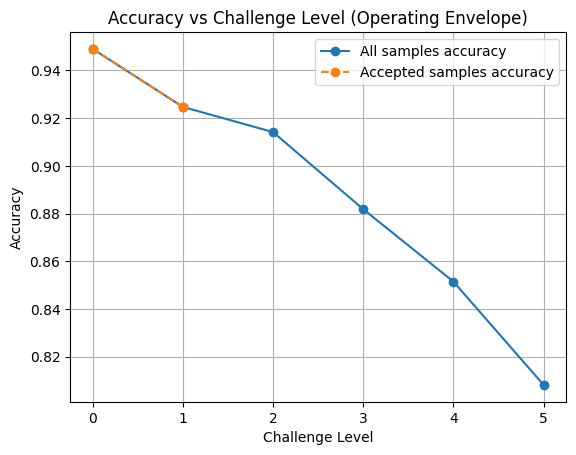

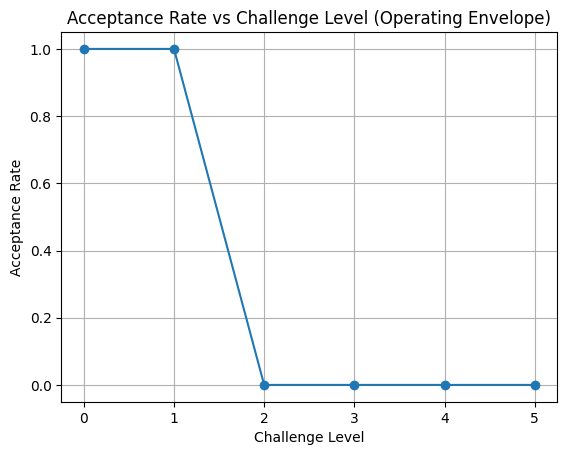

In [52]:
import matplotlib.pyplot as plt

levels = sorted(per_level_stats.keys())

accuracy = [per_level_stats[l]["accuracy"] for l in levels]
accept_rate = [per_level_stats[l]["accept_rate"] for l in levels]
accepted_acc = [per_level_stats[l]["accepted_accuracy"] for l in levels]

# --------------------------
# Plot 1: Accuracy vs Level
# --------------------------
plt.figure()
plt.plot(levels, accuracy, marker='o', label="All samples accuracy")                                    # original accuracy
plt.plot(levels, accepted_acc, marker='o', linestyle='--', label="Accepted samples accuracy")           # envelope accuracy

plt.xlabel("Challenge Level")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Challenge Level (Operating Envelope)")
plt.legend()
plt.grid(True)
plt.show()


# -------------------------------------
# Plot 2: Acceptance Rate vs Level
# -------------------------------------
plt.figure()
plt.plot(levels, accept_rate, marker='o')

plt.xlabel("Challenge Level")
plt.ylabel("Acceptance Rate")
plt.title("Acceptance Rate vs Challenge Level (Operating Envelope)")
plt.grid(True)
plt.show()

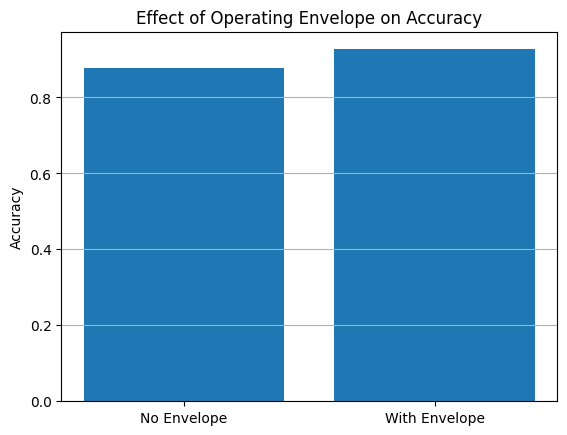

In [53]:
# -------------------------------------
# Plot 3: Before vs After Envelope
# -------------------------------------
overall_acc = envelope_results["overall_accuracy_no_reject"]
accepted_acc = envelope_results["accepted_accuracy"]

plt.figure()

plt.bar(["No Envelope", "With Envelope"], [overall_acc, accepted_acc])

plt.ylabel("Accuracy")
plt.title("Effect of Operating Envelope on Accuracy")

plt.grid(axis='y')
plt.show()

### 5.2 Add uncertainty gating

In [54]:
# =========================================================
# 5.2 Add uncertainty gating
# =========================================================

# 5.2.1 Helper functions
# 只在 被接受的样本 上算准确率
def selective_accuracy(probs: torch.Tensor, labels: torch.Tensor, accept_mask: torch.Tensor) -> float:
    accept_mask = accept_mask.bool()
    if accept_mask.sum().item() == 0:
        return float("nan")

    preds = probs.argmax(dim=1)
    acc = (preds[accept_mask] == labels[accept_mask]).float().mean().item()
    return float(acc)

# 给 logits 做 temperature scaling
# z′= z/T
def apply_temperature_to_logits(logits: torch.Tensor, temperature: float) -> torch.Tensor:
    temperature = max(float(temperature), 1e-6)
    return logits / temperature

# 在 calibration set 上，学一个单独的标量 T，使得 NLL 最小。
# temperature 的核心作用是：把过于尖锐、过于自信的概率分布压平一点
# T > 1 usually softens overconfident predictions
def learn_temperature_from_logits(
    logits: torch.Tensor,
    labels: torch.Tensor,
    init_temperature: float = 1.0,
    max_iter: int = 50
) -> float:
    """
    Learn one scalar temperature on the calibration set by minimizing NLL.
    T > 1 usually softens overconfident predictions.
    """
    logits = logits.detach().clone()
    labels = labels.detach().clone()

    temperature = torch.nn.Parameter(torch.tensor([init_temperature], dtype=torch.float32))
    optimizer = torch.optim.LBFGS([temperature], lr=0.01, max_iter=max_iter)

    def closure():
        optimizer.zero_grad()
        t = torch.clamp(temperature, min=1e-6)
        loss = F.cross_entropy(logits / t, labels)
        loss.backward()
        return loss

    optimizer.step(closure)
    learned_t = float(torch.clamp(temperature.detach(), min=1e-6).item())
    return learned_t


# 5.2.2 find msp threshold based on coverage
# find msp based on expected data coverage
def find_msp_threshold_for_target_coverage(
    probs: torch.Tensor,
    target_coverage: float = 0.90
) -> float:
    """
    Keep approximately the top target_coverage fraction of samples by MSP.
    Example: target_coverage=0.90 -> accept about 90%.
    """
    scores = max_softmax_probability(probs)
    sorted_scores, _ = torch.sort(scores, descending=True)

    k = max(1, int(math.ceil(len(sorted_scores) * target_coverage)))
    threshold = sorted_scores[k - 1]
    return float(threshold.item())


def find_entropy_threshold_for_target_coverage(
    probs: torch.Tensor,
    target_coverage: float = 0.90
) -> float:
    """
    Keep approximately the top target_coverage fraction of samples by low entropy.
    Lower entropy = more confident.
    """
    scores = predictive_entropy(probs)
    sorted_scores, _ = torch.sort(scores, descending=False)

    k = max(1, int(math.ceil(len(sorted_scores) * target_coverage)))
    threshold = sorted_scores[k - 1]
    return float(threshold.item())


# 5.2.3 find msp threshold based on target risk
def find_msp_threshold_for_target_risk(
    probs: torch.Tensor,
    labels: torch.Tensor,
    target_risk: float = 0.05
) -> float:
    """
    Sort by MSP descending and keep the largest accepted prefix
    whose empirical selective risk <= target_risk.
    """
    confidences = max_softmax_probability(probs)
    preds = probs.argmax(dim=1)
    errors = (preds != labels).float()

    order = torch.argsort(confidences, descending=True)
    sorted_conf = confidences[order]
    sorted_err = errors[order]

    cum_err = torch.cumsum(sorted_err, dim=0)
    counts = torch.arange(1, len(sorted_err) + 1, dtype=torch.float32)
    cum_risk = cum_err / counts

    valid = torch.where(cum_risk <= target_risk)[0]
    if len(valid) == 0:
        return float("inf")   # reject all

    best_idx = valid[-1]
    return float(sorted_conf[best_idx].item())


def find_entropy_threshold_for_target_risk(
    probs: torch.Tensor,
    labels: torch.Tensor,
    target_risk: float = 0.05
) -> float:
    """
    Sort by entropy ascending and keep the largest accepted prefix
    whose empirical selective risk <= target_risk.
    """
    ent = predictive_entropy(probs)
    preds = probs.argmax(dim=1)
    errors = (preds != labels).float()

    order = torch.argsort(ent, descending=False)
    sorted_ent = ent[order]
    sorted_err = errors[order]

    cum_err = torch.cumsum(sorted_err, dim=0)
    counts = torch.arange(1, len(sorted_err) + 1, dtype=torch.float32)
    cum_risk = cum_err / counts

    valid = torch.where(cum_risk <= target_risk)[0]
    if len(valid) == 0:
        return float("-inf")  # reject all for entropy gating

    best_idx = valid[-1]
    return float(sorted_ent[best_idx].item())


# 5.2.4 Main functions
def build_accept_mask_from_threshold(
    probs: torch.Tensor,
    gating_score: str,
    threshold: float
) -> torch.Tensor:
    gating_score = gating_score.lower()

    if gating_score == "msp":
        if math.isinf(threshold) and threshold > 0:
            return torch.zeros(len(probs), dtype=torch.bool)
        return accept_by_msp(probs, threshold)

    elif gating_score == "entropy":
        if math.isinf(threshold) and threshold < 0:
            return torch.zeros(len(probs), dtype=torch.bool)
        return accept_by_entropy(probs, threshold)

    else:
        raise ValueError("gating_score must be 'msp' or 'entropy'")


def choose_threshold_from_calibration(
    probs: torch.Tensor,
    labels: torch.Tensor,
    gating_score: str = "msp",
    threshold_mode: str = "coverage",
    target_coverage: float = 0.90,
    target_risk: float = 0.05
) -> float:
    gating_score = gating_score.lower()
    threshold_mode = threshold_mode.lower()

    if threshold_mode == "coverage":
        if gating_score == "msp":
            return find_msp_threshold_for_target_coverage(probs, target_coverage=target_coverage)
        elif gating_score == "entropy":
            return find_entropy_threshold_for_target_coverage(probs, target_coverage=target_coverage)

    elif threshold_mode == "risk":
        if gating_score == "msp":
            return find_msp_threshold_for_target_risk(probs, labels, target_risk=target_risk)
        elif gating_score == "entropy":
            return find_entropy_threshold_for_target_risk(probs, labels, target_risk=target_risk)

    raise ValueError("Unsupported threshold_mode / gating_score combination.")


def evaluate_uncertainty_gating(
    model,
    calib_loader,
    test_loader,
    device="cpu",
    use_temperature_scaling: bool = True,
    gating_score: str = "msp",          # "msp" or "entropy"
    threshold_mode: str = "coverage",   # "coverage" or "risk"
    target_coverage: float = 0.90,
    target_risk: float = 0.05,
    n_bins: int = 15
):
    """
    Calibration set:
        1) learn temperature (optional)
        2) choose gating threshold

    Test set:
        report coverage / selective accuracy / selective risk on accepted samples only
    """
    # -------------------------------------------------------------------------
    # 1. Collect calibration / test outputs with metadata
    # -------------------------------------------------------------------------
    calib_out = collect_outputs_with_metadata(model, calib_loader, device=device)
    test_out  = collect_outputs_with_metadata(model, test_loader,  device=device)

    calib_logits = calib_out["logits"]
    calib_labels = calib_out["labels"]

    test_logits = test_out["logits"]
    test_labels = test_out["labels"]

    calib_probs_before = calib_out["probs"].clone()
    test_probs_before  = test_out["probs"].clone()

    # -------------------------------------------------------------------------
    # 2. Optional temperature scaling on calibration set
    # -------------------------------------------------------------------------
    temperature = 1.0
    if use_temperature_scaling:
        temperature = learn_temperature_from_logits(calib_logits, calib_labels)

    calib_probs_after = torch.softmax(apply_temperature_to_logits(calib_logits, temperature), dim=1)
    test_probs_after  = torch.softmax(apply_temperature_to_logits(test_logits,  temperature), dim=1)

    calib_out["probs_raw"] = calib_probs_before
    calib_out["probs"] = calib_probs_after

    test_out["probs_raw"] = test_probs_before
    test_out["probs"] = test_probs_after

    # -------------------------------------------------
    # 3. Choose threshold on calibration set only
    # 阈值必须只在 calibration set 上定，threshold as a param
    # -------------------------------------------------
    threshold = choose_threshold_from_calibration(
        probs=calib_probs_after,
        labels=calib_labels,
        gating_score=gating_score,
        threshold_mode=threshold_mode,
        target_coverage=target_coverage,
        target_risk=target_risk
    )

    # -------------------------------------------------
    # 4. Apply threshold to both calibration / test
    # 把阈值应用到 calibration 和 test
    # -------------------------------------------------
    calib_accept_mask = build_accept_mask_from_threshold(
        probs=calib_probs_after,
        gating_score=gating_score,
        threshold=threshold
    )

    test_accept_mask = build_accept_mask_from_threshold(
        probs=test_probs_after,
        gating_score=gating_score,
        threshold=threshold
    )

    # -------------------------
    # 5. Summaries
    # -------------------------
    # 还没做 temperature scaling 之前，概率质量怎么样
    calib_before_metrics = {
        "accuracy": clean_accuracy_from_probs(calib_probs_before, calib_labels),
        "ECE": expected_calibration_error(calib_probs_before, calib_labels, n_bins=n_bins),
        "NLL": negative_log_likelihood(calib_probs_before, calib_labels),
        "Brier": brier_score(calib_probs_before, calib_labels),
    }

    # 这里多了 selective 指标，因为 gating 已经发生了
    calib_after_metrics = {
        "accuracy": clean_accuracy_from_probs(calib_probs_after, calib_labels),
        "ECE": expected_calibration_error(calib_probs_after, calib_labels, n_bins=n_bins),
        "NLL": negative_log_likelihood(calib_probs_after, calib_labels),
        "Brier": brier_score(calib_probs_after, calib_labels),
        "coverage": coverage(calib_accept_mask),
        "selective_risk": selective_risk(calib_probs_after, calib_labels, calib_accept_mask),
        "selective_accuracy": selective_accuracy(calib_probs_after, calib_labels, calib_accept_mask),
    }

    test_results = {
        "overall_accuracy_no_reject": clean_accuracy_from_probs(test_probs_after, test_labels),    # 如果不做拒绝，test set 全部预测，准确率是多少
        "coverage": coverage(test_accept_mask),                                                    # 经过 gating 后，还剩多少比例样本
        "accepted_accuracy": selective_accuracy(test_probs_after, test_labels, test_accept_mask),  # 只在通过 gating 的样本上，准确率是多少
        "accepted_risk": selective_risk(test_probs_after, test_labels, test_accept_mask),          # 只在通过 gating 的样本上，错误率是多少
        "ECE": expected_calibration_error(test_probs_after, test_labels, n_bins=n_bins),
        "NLL": negative_log_likelihood(test_probs_after, test_labels),
        "Brier": brier_score(test_probs_after, test_labels),
        "num_total": int(len(test_labels)),
        "num_accepted": int(test_accept_mask.sum().item()),
        "num_rejected": int((~test_accept_mask).sum().item()),
    }

    summary = {
        "gating_score": gating_score,
        "threshold_mode": threshold_mode,
        "target_coverage": target_coverage if threshold_mode == "coverage" else None,
        "target_risk": target_risk if threshold_mode == "risk" else None,
        "temperature": float(temperature),
        "threshold": float(threshold),
        "calib_before": calib_before_metrics,
        "calib_after": calib_after_metrics,
        "test_results": test_results,
    }

    return summary, calib_out, test_out, calib_accept_mask, test_accept_mask


# -------------------------
# Example run
# calibration set: small_Real_Val_20
# Calibration set的作用：
    # 第一，学 temperature（learn_temperature_from_logits）：在 calibration set 上，通过最小化交叉熵/NLL 来找一个最合适的温度
    # 第二，选 gating threshold（choose_threshold_from_calibration）
# final test set:  small_Real_Test
# -------------------------
uncertainty_results, calib_out, test_out, calib_mask, test_mask = evaluate_uncertainty_gating(
    model=resnet_model,
    calib_loader=small_Real_Val_20,
    test_loader=small_Real_Test,
    device=device,
    use_temperature_scaling=True,
    gating_score="msp",
    threshold_mode="coverage",   # choose: "coverage" or "risk"
    target_coverage=0.90,        # keep about 90% -> 10000 images -> about 9000 accepted
    target_risk=0.05,            # only used when threshold_mode="risk"
    n_bins=15
)

print("5.2 Uncertainty Gating Results")
print(f"gating_score     : {uncertainty_results['gating_score']}")
print(f"threshold_mode   : {uncertainty_results['threshold_mode']}")
print(f"temperature      : {uncertainty_results['temperature']:.4f}")
print(f"threshold        : {uncertainty_results['threshold']:.4f}")

print("Calibration set (before temperature scaling):")
for k, v in uncertainty_results["calib_before"].items():
    print(f"{k}: {v:.4f}")

print("Calibration set (after temperature scaling + gating):")
for k, v in uncertainty_results["calib_after"].items():
    print(f"{k}: {v:.4f}")

print("Test set results:")
for k, v in uncertainty_results["test_results"].items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")



/tmp/ipykernel_3210433/3773634050.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  all_levels.append(torch.tensor(batch["challengeLevel"]))
/tmp/ipykernel_3210433/3773634050.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  all_challenge_types.append(torch.tensor(batch["challengeType"]))


5.2 Uncertainty Gating Results
gating_score     : msp
threshold_mode   : coverage
temperature      : 0.9866
threshold        : 0.9911
Calibration set (before temperature scaling):
accuracy: 0.9818
ECE: 0.0019
NLL: 0.0573
Brier: 0.0261
Calibration set (after temperature scaling + gating):
accuracy: 0.9818
ECE: 0.0020
NLL: 0.0573
Brier: 0.0261
coverage: 0.9000
selective_risk: 0.0003
selective_accuracy: 0.9997
Test set results:
overall_accuracy_no_reject: 0.8771
coverage: 0.7121
accepted_accuracy: 0.9847
accepted_risk: 0.0153
ECE: 0.0609
NLL: 0.4797
Brier: 0.1859
num_total: 101687
num_accepted: 72414
num_rejected: 29273


/home/hice1/yan84/Fund_of_ML/venv/lib64/python3.9/site-packages/torch/optim/lbfgs.py:457: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  loss = float(closure())


### 5.2.2 Plot

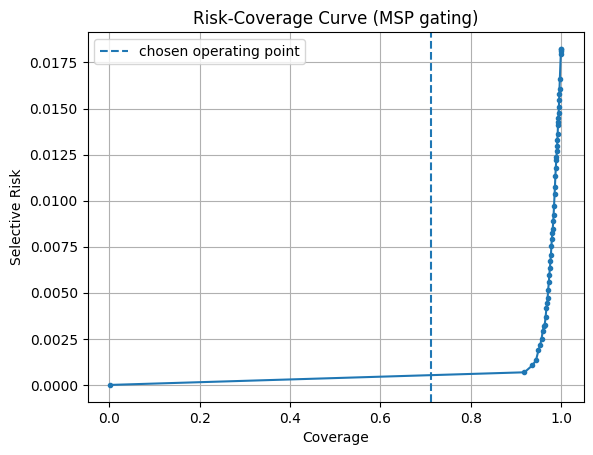

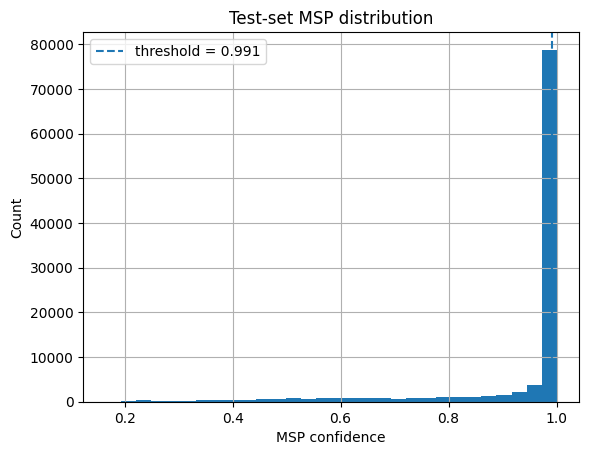

{0: {'accuracy': 0.9489735960960388, 'accept_rate': 0.8387096524238586, 'accepted_accuracy': 0.9986013770103455}, 1: {'accuracy': 0.9246616959571838, 'accept_rate': 0.8048374056816101, 'accepted_accuracy': 0.9910283088684082}, 2: {'accuracy': 0.9141245484352112, 'accept_rate': 0.781716525554657, 'accepted_accuracy': 0.9903557300567627}, 3: {'accuracy': 0.8818041086196899, 'accept_rate': 0.7299805283546448, 'accepted_accuracy': 0.9834597706794739}, 4: {'accuracy': 0.851460874080658, 'accept_rate': 0.6666499972343445, 'accepted_accuracy': 0.98003751039505}, 5: {'accuracy': 0.8081817030906677, 'accept_rate': 0.5682473182678223, 'accepted_accuracy': 0.9734079837799072}}


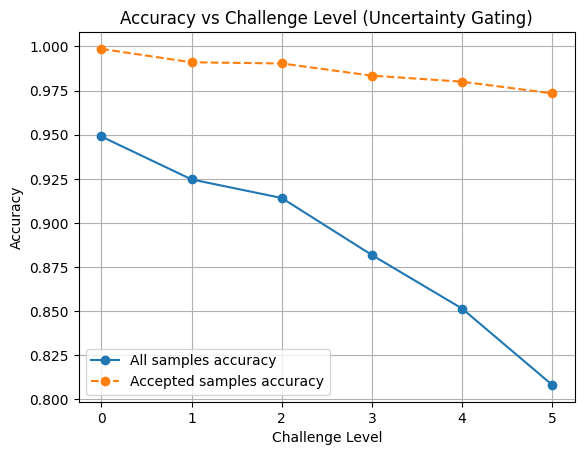

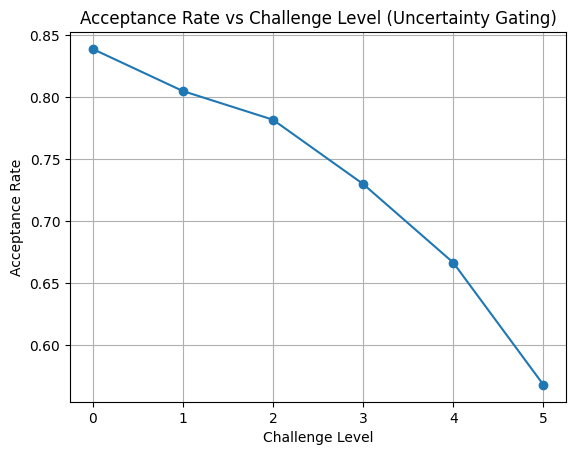

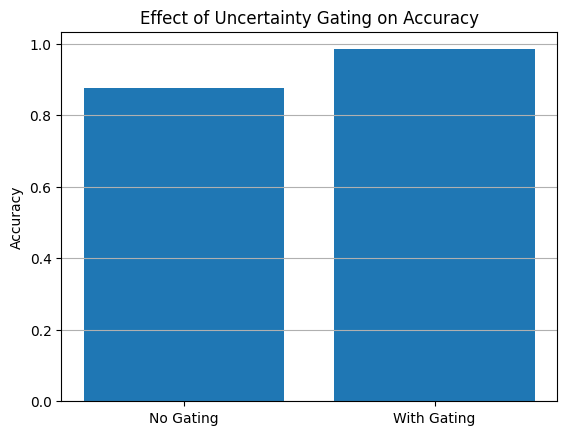

In [55]:
# =========================================================
# 5.2.2 Plot
# =========================================================

# 1) Risk-Coverage curve on calibration set
# risk = accepted wrong / accepted total
curve = risk_coverage_curve_from_msp(calib_out["probs"], calib_out["labels"], num_thresholds=50)

curve_coverages = [row["coverage"] for row in curve]
curve_risks = [row["risk"] for row in curve]

plt.figure()
plt.plot(curve_coverages, curve_risks, marker="o", markersize=3)
plt.axvline(uncertainty_results["test_results"]["coverage"], linestyle="--", label="chosen operating point")
plt.xlabel("Coverage")
plt.ylabel("Selective Risk")
plt.title("Risk-Coverage Curve (MSP gating)")
plt.grid(True)
plt.legend()
plt.show()


# 2) Confidence histogram on test set + chosen threshold
test_msp = max_softmax_probability(test_out["probs"]).numpy()
threshold = uncertainty_results["threshold"]

plt.figure()
plt.hist(test_msp, bins=30)
plt.axvline(threshold, linestyle="--", label=f"threshold = {threshold:.3f}")
plt.xlabel("MSP confidence")
plt.ylabel("Count")
plt.title("Test-set MSP distribution")
plt.grid(True)
plt.legend()
plt.show()


# 3) Per-level stats after uncertainty gating
per_level_stats_gating = compute_per_level_stats(test_out, test_mask)
print(per_level_stats_gating)

levels = sorted(per_level_stats_gating.keys())
accuracy = [per_level_stats_gating[l]["accuracy"] for l in levels]
accept_rate = [per_level_stats_gating[l]["accept_rate"] for l in levels]
accepted_acc = [per_level_stats_gating[l]["accepted_accuracy"] for l in levels]

plt.figure()
plt.plot(levels, accuracy, marker='o', label="All samples accuracy")
plt.plot(levels, accepted_acc, marker='o', linestyle='--', label="Accepted samples accuracy")
plt.xlabel("Challenge Level")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Challenge Level (Uncertainty Gating)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(levels, accept_rate, marker='o')
plt.xlabel("Challenge Level")
plt.ylabel("Acceptance Rate")
plt.title("Acceptance Rate vs Challenge Level (Uncertainty Gating)")
plt.grid(True)
plt.show()


# 4) Before vs after gating
overall_acc = uncertainty_results["test_results"]["overall_accuracy_no_reject"]
accepted_acc = uncertainty_results["test_results"]["accepted_accuracy"]

plt.figure()
plt.bar(["No Gating", "With Gating"], [overall_acc, accepted_acc])
plt.ylabel("Accuracy")
plt.title("Effect of Uncertainty Gating on Accuracy")
plt.grid(axis='y')
plt.show()

